# Math Genealogy: Exploratory Data Analysis

Analysis of the cleaned graph (`graph.pkl`) from `build_graph.py`.

## Sections
1. Basic graph statistics
2. Network science measures
3. PhDs over time (per year + cumulative)
4. PhDs normalized by world population
5. Top universities
6. Top countries
7. Top subjects


In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="ticks", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
pd.options.display.max_columns = None
pd.options.display.width = 120

# Resolve graph.pkl whether CWD is the notebook dir (analysis/) or the project root
for _candidate in ("graph.pkl", "analysis/graph.pkl", "../analysis/graph.pkl"):
    if Path(_candidate).exists():
        GRAPH_PATH = Path(_candidate)
        break
else:
    raise FileNotFoundError("graph.pkl not found; run `python analysis/build_graph.py` first")

with open(GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

# Tabular view of node metadata for easier slicing
df = pd.DataFrame(
    [{"id": n, **a} for n, a in G.nodes(data=True)]
).set_index("id")

print(f"loaded {GRAPH_PATH}")
print(f"  {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
df.head()


loaded graph.pkl
  262,967 nodes, 285,398 edges


,name,thesis,school,country,year,subject
id,,,,,,
11,Alfred E. Engelbrecht,Coupled Bending and Torsional Free Vibration o...,Iowa State University,UnitedStates,1949.0,NaN
4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,NaN
1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,74—Mechanics of deformable solids
7,Carl Eric Langenhop,Properties of Kernels of Integral Equations Wh...,Iowa State University,UnitedStates,1948.0,NaN
6,William B. Stiles,Solutions of Clamped Plated Problems by Means ...,Iowa State University,UnitedStates,1945.0,NaN


## 1. Basic graph statistics


In [2]:
n, m = G.number_of_nodes(), G.number_of_edges()
print(f"# nodes:     {n:>12,}")
print(f"# edges:     {m:>12,}")
print(f"directed?    {G.is_directed()}")
print(f"DAG?         {nx.is_directed_acyclic_graph(G)}")
print(f"density:     {nx.density(G):>12.2e}")
print(f"avg degree:  {2 * m / n:>12.2f}  (avg in-degree = avg out-degree = m/n)")

print("\nMetadata coverage:")
for field in ["name", "year", "school", "country", "subject", "thesis"]:
    coverage = df[field].notna().sum()
    print(f"  {field:<10} {coverage:>10,} / {n:,}  ({coverage / n:.1%})")


# nodes:          262,967
# edges:          285,398
directed?    True
DAG?         True
density:         4.13e-06
avg degree:          2.17  (avg in-degree = avg out-degree = m/n)

Metadata coverage:
  name          262,120 / 262,967  (99.7%)
  year          214,713 / 262,967  (81.7%)
  school        220,346 / 262,967  (83.8%)
  country       247,462 / 262,967  (94.1%)
  subject       153,714 / 262,967  (58.5%)
  thesis        234,799 / 262,967  (89.3%)


## 2. Network science measures

Following conventions from [Network Science](https://networksciencebook.com/) by Barabási. The most relevant chapters here: Ch 2 (basic stats), Ch 3 (random reference), Ch 4 (scale-free), Ch 7 (degree correlations).


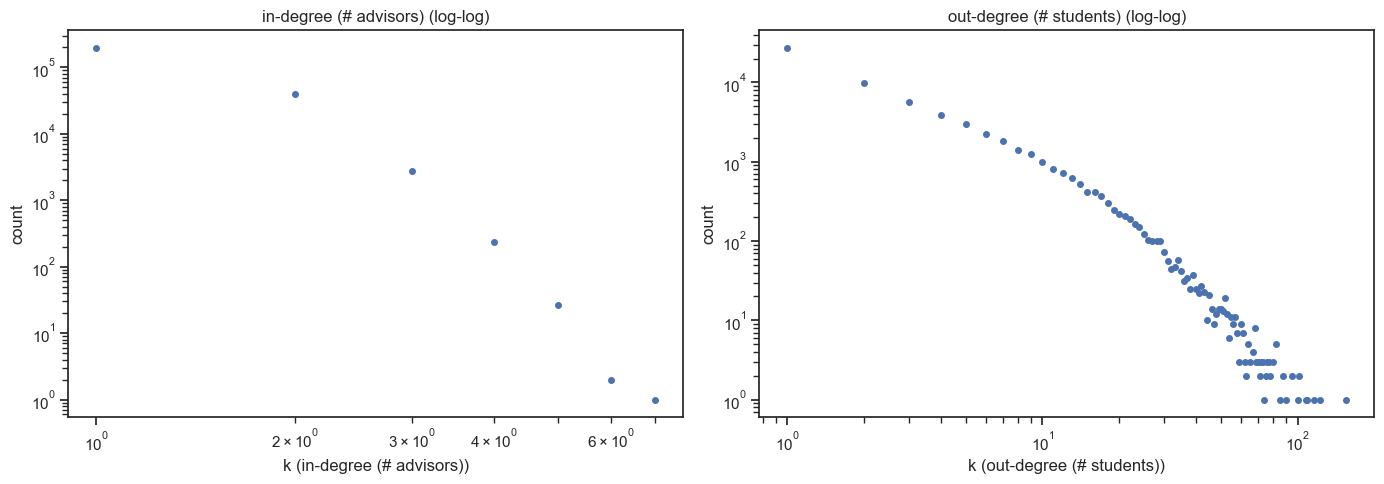

,in_degree,out_degree
count,262967.00000,262967.000000
mean,1.08530,1.085300
std,0.53814,3.803791
min,0.00000,0.000000
25%,1.00000,0.000000
50%,1.00000,0.000000
75%,1.00000,0.000000
max,7.00000,155.000000


In [3]:
# Degree distribution — in (# advisors) and out (# students)
in_deg = pd.Series(dict(G.in_degree()))
out_deg = pd.Series(dict(G.out_degree()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, deg, label in zip(axes, [in_deg, out_deg], ["in-degree (# advisors)", "out-degree (# students)"]):
    counts = deg[deg > 0].value_counts().sort_index()
    ax.loglog(counts.index, counts.values, "o", markersize=4)
    ax.set_xlabel(f"k ({label})")
    ax.set_ylabel("count")
    ax.set_title(f"{label} (log-log)")
plt.tight_layout()
plt.show()

pd.DataFrame({"in_degree": in_deg.describe(), "out_degree": out_deg.describe()})


# weakly-connected components:        13,355
# strongly-connected components:     262,967
giant WCC size:                      239,464  (91.1% of all nodes)


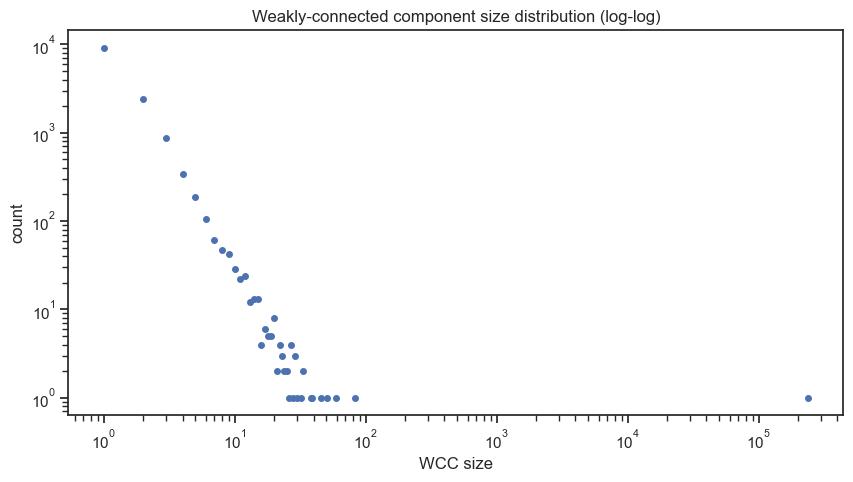

In [4]:
# Connected components
wccs = list(nx.weakly_connected_components(G))
sccs = list(nx.strongly_connected_components(G))
giant_wcc = max(wccs, key=len)

print(f"# weakly-connected components:    {len(wccs):>10,}")
print(f"# strongly-connected components:  {len(sccs):>10,}")
print(f"giant WCC size:                   {len(giant_wcc):>10,}  ({len(giant_wcc) / G.number_of_nodes():.1%} of all nodes)")

wcc_sizes = pd.Series([len(c) for c in wccs])
size_counts = wcc_sizes.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(size_counts.index, size_counts.values, "o", markersize=4)
ax.set_xlabel("WCC size")
ax.set_ylabel("count")
ax.set_title("Weakly-connected component size distribution (log-log)")
plt.show()


sample: 200 sources, 47,892,800 reachable pairs (undirected, giant WCC)
  mean shortest path:        12.44
  median:                    12
  max (≤ true diameter):     41


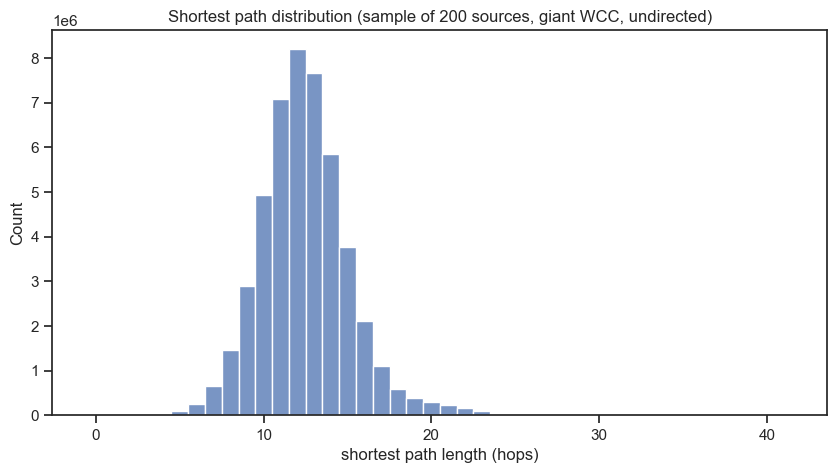

In [5]:
# Average shortest path length / approximate diameter (sampled BFS sources)
SAMPLE = 200
RNG = np.random.default_rng(0)
sources = RNG.choice(list(giant_wcc), size=SAMPLE, replace=False)
H = G.to_undirected().subgraph(giant_wcc)

lengths = []
for src in sources:
    sp = nx.single_source_shortest_path_length(H, src)
    lengths.extend(sp.values())
lengths = pd.Series(lengths)

print(f"sample: {SAMPLE} sources, {len(lengths):,} reachable pairs (undirected, giant WCC)")
print(f"  mean shortest path:        {lengths.mean():.2f}")
print(f"  median:                    {lengths.median():.0f}")
print(f"  max (≤ true diameter):     {lengths.max()}")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(lengths, bins=range(0, int(lengths.max()) + 2), discrete=True, ax=ax)
ax.set_xlabel("shortest path length (hops)")
ax.set_title(f"Shortest path distribution (sample of {SAMPLE} sources, giant WCC, undirected)")
plt.show()


In [6]:
# Average local clustering vs. Erdős–Rényi random expectation
SAMPLE = 5000
H = G.to_undirected()
sample_nodes = RNG.choice(list(G.nodes), size=SAMPLE, replace=False)
local_cc = nx.clustering(H, sample_nodes)
avg_cc = float(np.mean(list(local_cc.values())))

p = nx.density(G)
print(f"average local clustering (n={SAMPLE} sample): {avg_cc:.4f}")
print(f"expected under Erdős–Rényi (p=density):       {p:.2e}")
print(f"actual / expected:                            {avg_cc / p:,.0f}x")
print("\nInterpretation: a clustering coefficient orders of magnitude above the")
print("random baseline indicates strong community structure — expected from an")
print("academic advisor network (advisors at the same school, era, subfield cluster).")


average local clustering (n=5000 sample): 0.0208
expected under Erdős–Rényi (p=density):       4.13e-06
actual / expected:                            5,043x

Interpretation: a clustering coefficient orders of magnitude above the
random baseline indicates strong community structure — expected from an
academic advisor network (advisors at the same school, era, subfield cluster).


In [7]:
# PageRank — fast on sparse DAGs and well-suited to ranking 'influence'.
pr = pd.Series(nx.pagerank(G, alpha=0.85)).sort_values(ascending=False)
top = df.loc[pr.head(20).index, ["name", "year", "school", "country"]].copy()
top["pagerank"] = pr.head(20).values
top.reset_index(drop=True)

,name,year,school,country,pagerank
0,Jean-Pierre Chièze,NaN,NaN,France,0.000018
1,Alexios Aivaliotis,2019.0,Université de Lyon,France,0.000018
2,Matthias Rungger,NaN,NaN,Germany,0.000018
3,Farzad Radmehr,2014.0,Ferdowsi University of Mashhad,Iran,0.000018
4,Ioannis M. Vandoulakis,1991.0,Lomonosov Moscow State University,Russia,0.000018
5,David Bou Saba,2018.0,Université de Lyon,France,0.000016
6,Patrick Casey,2013.0,State University of New York at Stony Brook,UnitedStates,0.000016
7,Isma Kaddouri,NaN,NaN,France,0.000016
8,Fernando Castro-Chávez,2006.0,Universidad de Guadalajara,Mexico,0.000016
9,Bradley S Stewart,1988.0,University of Virginia,UnitedStates,0.000015


## 3. PhDs over time


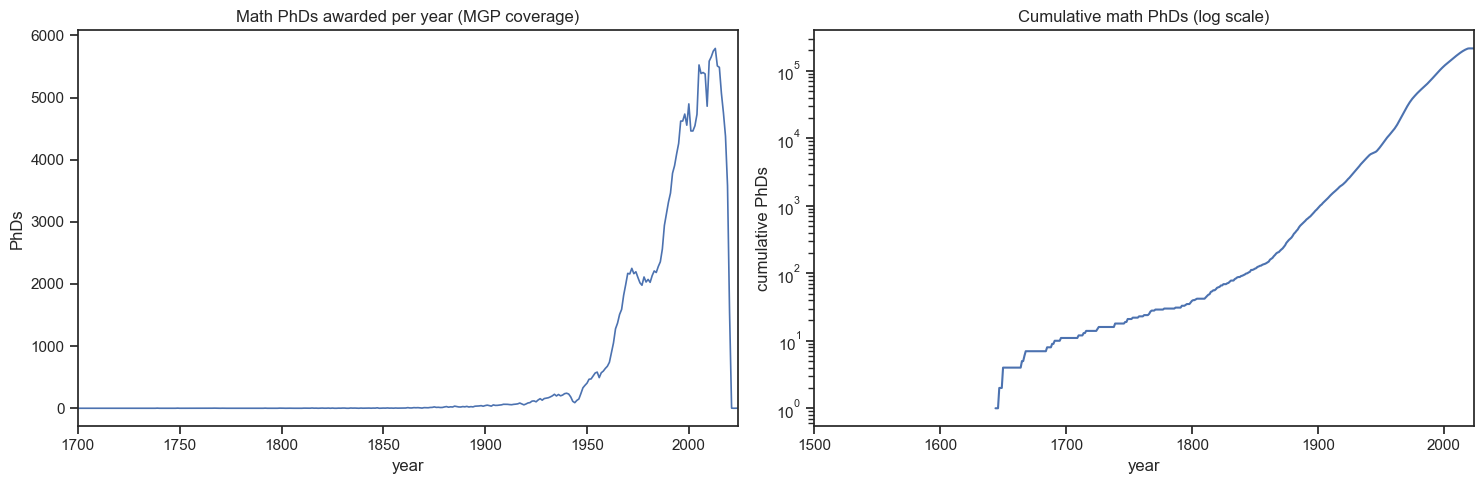

In [8]:
years = df["year"].dropna().astype(int)
years = years[(years >= 1500) & (years <= 2025)]
y_min, y_max = int(years.min()), int(years.max())

# Reindex only up to the last year actually in the data so the line doesn't
# drop to 0 past the data's end.
per_year = years.value_counts().sort_index().reindex(range(y_min, y_max + 1), fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(per_year.index, per_year.values, linewidth=1.2)
axes[0].set_title("Math PhDs awarded per year (MGP coverage)")
axes[0].set_xlabel("year")
axes[0].set_ylabel("PhDs")
axes[0].set_xlim(1700, y_max)

axes[1].plot(per_year.index, per_year.cumsum().values, linewidth=1.5)
axes[1].set_title("Cumulative math PhDs (log scale)")
axes[1].set_xlabel("year")
axes[1].set_ylabel("cumulative PhDs")
axes[1].set_yscale("log")
axes[1].set_xlim(1500, y_max)
plt.tight_layout()
plt.show()


## 4. PhDs normalized by world population

World population anchors below combine:
- **HYDE 3.3** (Klein Goldewijk et al., 2017) — the canonical historical population dataset used by Our World in Data — for years 1500–1950
- **UN World Population Prospects 2024** for 1950 onward

Linear interpolation between anchors. Units: millions of people.


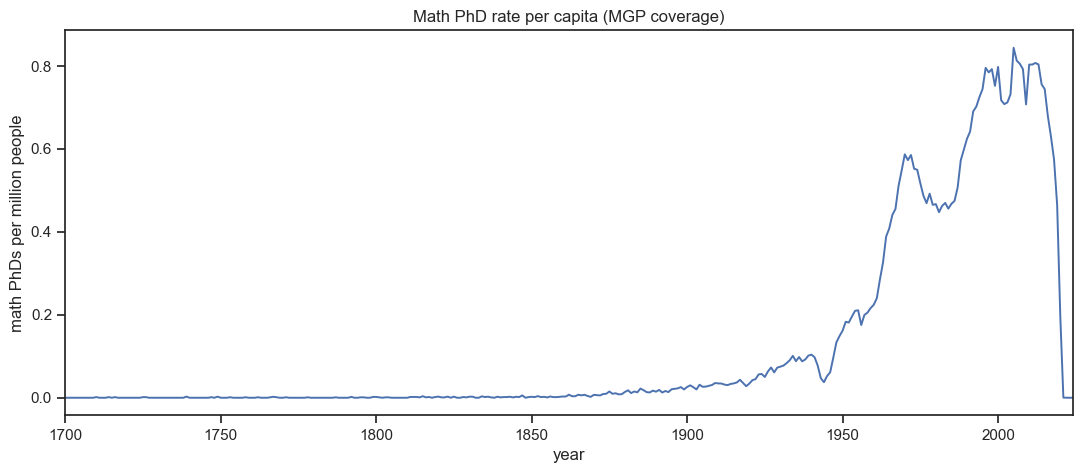

In [9]:
WORLD_POP_MILLIONS = pd.Series({
    1500:  461, 1600:  554, 1700:  603, 1750:  770,
    1800:  989, 1850: 1262, 1900: 1654,
    1950: 2499, 1960: 3019, 1970: 3700, 1980: 4444,
    1990: 5316, 2000: 6143, 2010: 6957, 2020: 7795, 2024: 8119,
})
pop_full = WORLD_POP_MILLIONS.reindex(range(1500, 2025)).interpolate()
# Intersect with per_year so we don't extend past the data's last year
rate = (per_year / pop_full).dropna()  # PhDs per million people

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(rate.index, rate.values, linewidth=1.4)
ax.set_xlim(1700, int(rate.index.max()))
ax.set_xlabel("year")
ax.set_ylabel("math PhDs per million people")
ax.set_title("Math PhD rate per capita (MGP coverage)")
plt.show()


## 5. Top universities


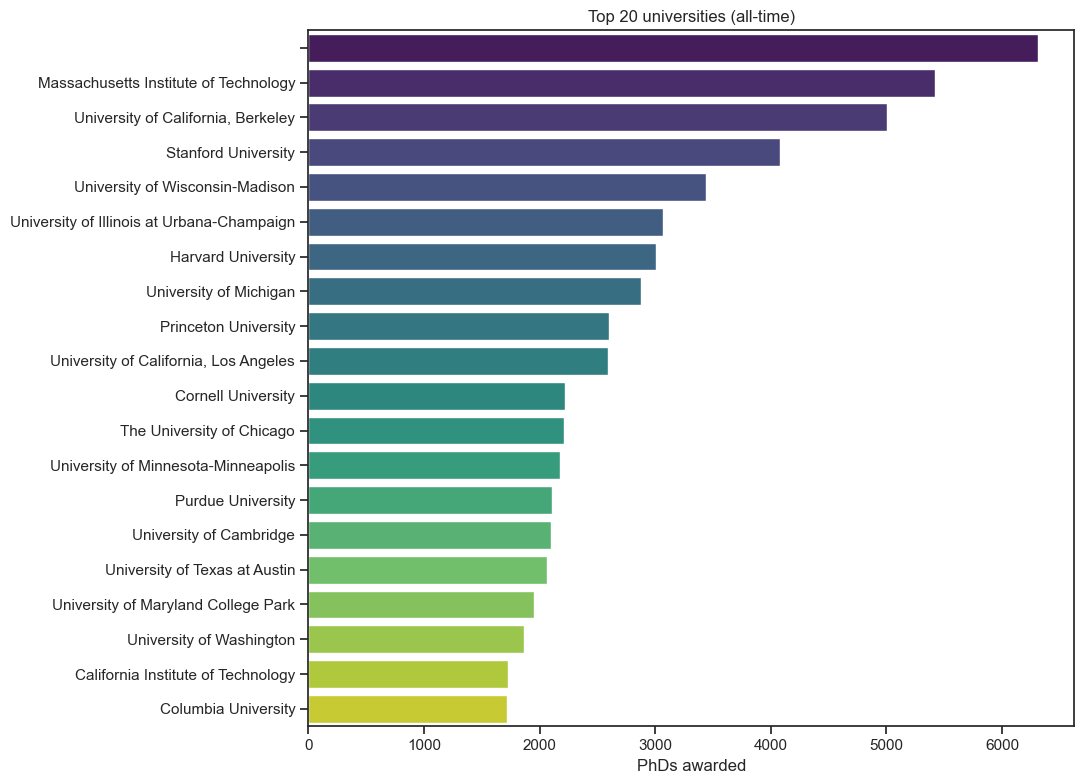

,era,school,count
0,1700,,1
1,1700,Académie royale des sciences de Paris,1
2,1700,Friedrich-Schiller-Universität Jena,1
3,1700,Les Hôpitals de la Charité et Salpêtrière de P...,1
4,1700,Philipps-Universität Marburg,1
5,1750,Uppsala Universitet,4
6,1750,Friedrich-Schiller-Universität Jena,2
7,1750,Georg-August-Universität Göttingen,2
8,1750,Eberhard-Karls-Universität Tübingen,1
9,1750,Friedrich-Alexander-Universität Erlangen-Nürnberg,1


In [10]:
top_schools = df["school"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(11, 8))
sns.barplot(x=top_schools.values, y=top_schools.index,
            hue=top_schools.index, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("PhDs awarded")
ax.set_ylabel("")
ax.set_title("Top 20 universities (all-time)")
plt.tight_layout()
plt.show()

# Top 5 schools per 50-year era
df_era = df.dropna(subset=["year", "school"]).copy()
df_era["year"] = df_era["year"].astype(int)
df_era = df_era[(df_era["year"] >= 1700) & (df_era["year"] <= 2024)]
df_era["era"] = (df_era["year"] // 50) * 50

top_per_era = (df_era.groupby(["era", "school"]).size()
               .groupby(level=0).nlargest(5)
               .reset_index(level=0, drop=True)
               .rename("count").reset_index())
top_per_era


## 6. Top countries


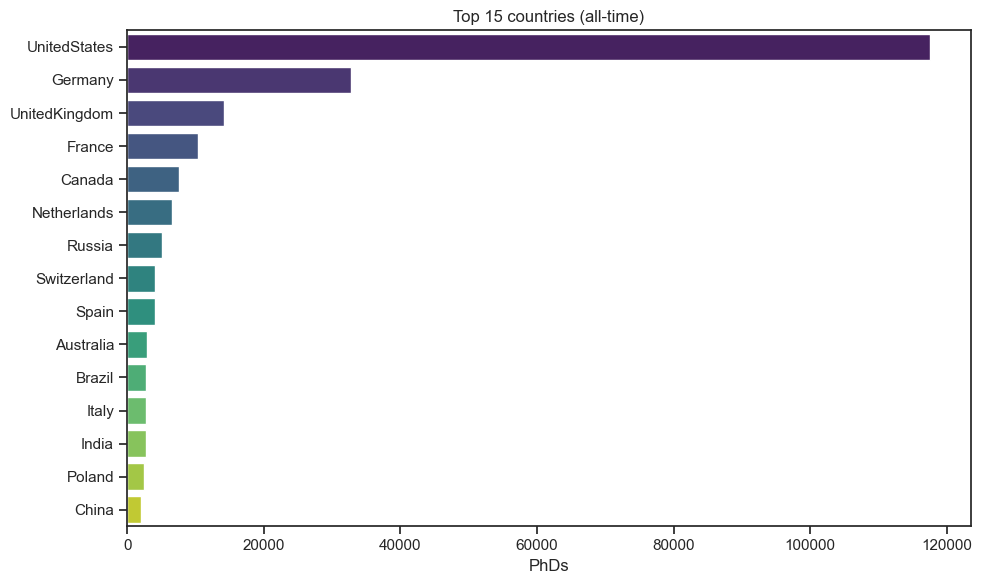

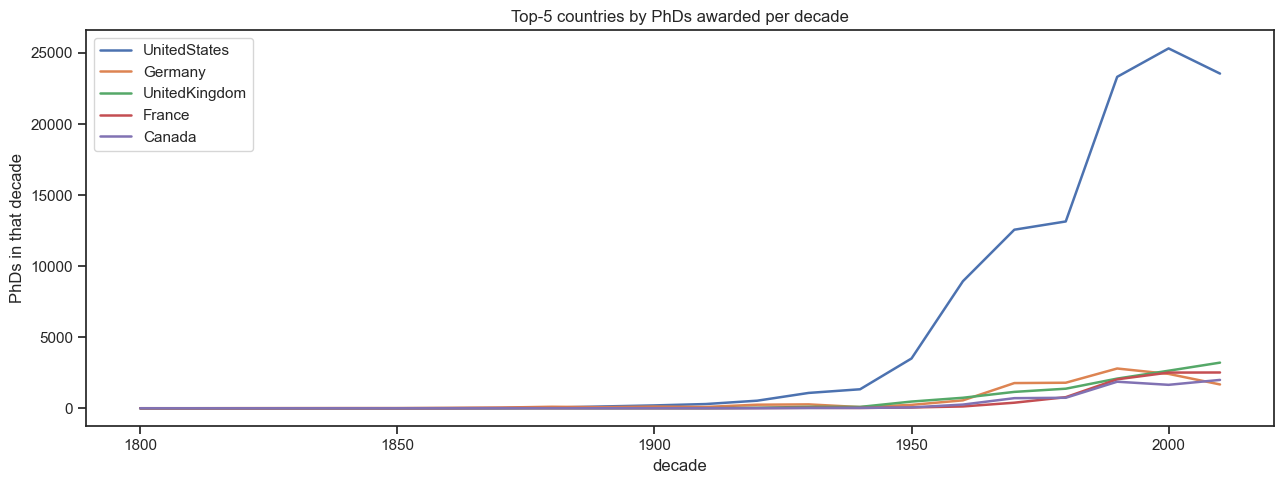

In [11]:
top_countries = df["country"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index,
            hue=top_countries.index, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("PhDs")
ax.set_ylabel("")
ax.set_title("Top 15 countries (all-time)")
plt.tight_layout()
plt.show()

# Top-5 countries over time (per decade). Drop the latest decade if incomplete
# so the lines don't drop to artificially low values at the end.
df_c = df.dropna(subset=["year", "country"]).copy()
df_c["year"] = df_c["year"].astype(int)
df_c = df_c[(df_c["year"] >= 1800) & (df_c["year"] <= 2024)]
last_year = df_c["year"].max()
last_decade = (last_year // 10) * 10
if last_year < last_decade + 9:
    df_c = df_c[df_c["year"] < last_decade]
df_c["decade"] = (df_c["year"] // 10) * 10

top_5_countries = df_c["country"].value_counts().head(5).index.tolist()
pivot = (df_c[df_c["country"].isin(top_5_countries)]
         .groupby(["decade", "country"]).size()
         .unstack(fill_value=0))[top_5_countries]

fig, ax = plt.subplots(figsize=(13, 5))
for c in top_5_countries:
    ax.plot(pivot.index, pivot[c].values, label=c, linewidth=1.8)
ax.set_xlabel("decade")
ax.set_ylabel("PhDs in that decade")
ax.set_title("Top-5 countries by PhDs awarded per decade")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Top subjects

MGP subjects use the 2-digit MSC (Mathematics Subject Classification) prefix — e.g. `"90—Operations research, mathematical programming"`. The prefix is stripped below for readability.


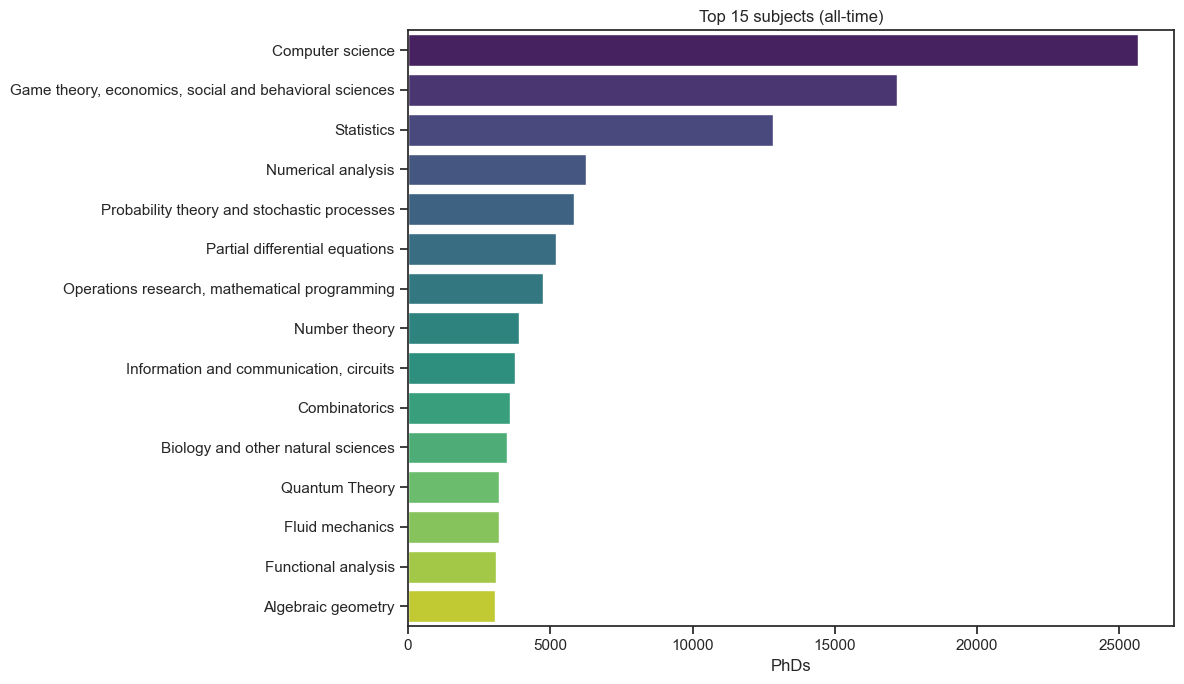

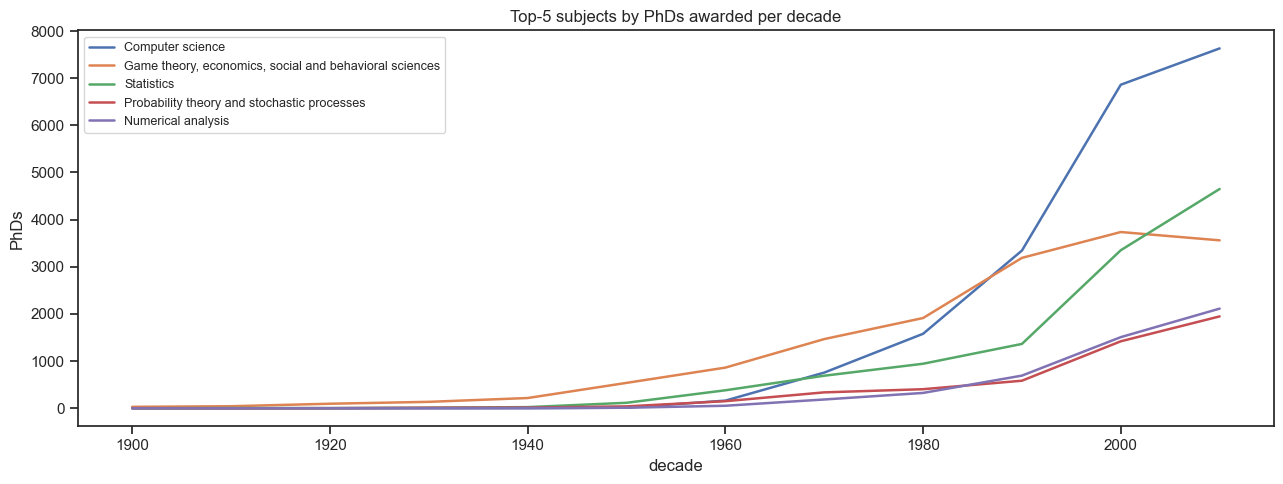

In [12]:
import re

def clean_subject(s):
    if not isinstance(s, str):
        return None
    return re.sub(r"^\d{2}\s*[—\-]?\s*", "", s)

df["subject_clean"] = df["subject"].map(clean_subject)
top_subjects = df["subject_clean"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=top_subjects.values, y=top_subjects.index,
            hue=top_subjects.index, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("PhDs")
ax.set_ylabel("")
ax.set_title("Top 15 subjects (all-time)")
plt.tight_layout()
plt.show()

# Top-5 subjects over time, dropping the latest incomplete decade
df_s = df.dropna(subset=["year", "subject_clean"]).copy()
df_s["year"] = df_s["year"].astype(int)
df_s = df_s[(df_s["year"] >= 1900) & (df_s["year"] <= 2024)]
last_year = df_s["year"].max()
last_decade = (last_year // 10) * 10
if last_year < last_decade + 9:
    df_s = df_s[df_s["year"] < last_decade]
df_s["decade"] = (df_s["year"] // 10) * 10

top_5_subjects = df_s["subject_clean"].value_counts().head(5).index.tolist()
pivot_s = (df_s[df_s["subject_clean"].isin(top_5_subjects)]
           .groupby(["decade", "subject_clean"]).size()
           .unstack(fill_value=0))[top_5_subjects]

fig, ax = plt.subplots(figsize=(13, 5))
for s in top_5_subjects:
    ax.plot(pivot_s.index, pivot_s[s].values, label=s, linewidth=1.8)
ax.set_xlabel("decade")
ax.set_ylabel("PhDs")
ax.set_title("Top-5 subjects by PhDs awarded per decade")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()
